# 1. Multi-Modal Setup & AI Extraction Engine

In this initial stage, we configure our **intelligent extraction layer**. We initialize **Docling** for structural PDF parsing and set up our dual-engine clients:
* **Groq (Llama 3.1):** Optimized for high-speed text processing and structured data extraction.
* **Google Gemini 1.5 Flash:** Leveraging multi-modal vision capabilities to extract data directly from page images.

By defining strict **Pydantic classes**, we ensure that every piece of data—whether sourced from text or image—is validated, typed, and ready for downstream business logic.

In [27]:
import os
import getpass
import base64
import io
import re
import json
from typing import TypedDict, Optional, List, Annotated, Literal
from datetime import datetime
from pydantic import BaseModel, Field

# Docling Imports
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption

# AI & Graph Imports
import groq
import google.generativeai as genai
from langgraph.graph import StateGraph, START, END

# --- Setup API Keys ---
if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter Groq API Key: ")
if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter Gemini API Key: ")

groq_client = groq.Groq(api_key=os.environ["GROQ_API_KEY"])
genai.configure(api_key=os.environ["GOOGLE_API_KEY"])

print("✅ All libraries imported and APIs configured!")

✅ All libraries imported and APIs configured!


In [28]:
# Define PDF conversion options
pipeline_options = PdfPipelineOptions()
pipeline_options.images_scale = 2  # جودة عالية للصور باش Gemini يقرا مزيان
pipeline_options.generate_page_images = True

# Initialize the converter
doc_converter = DocumentConverter(
    format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)}
)

# Convert the PDF
pdf_path = "./docs/pdf_invoice.pdf"

if os.path.exists(pdf_path):
    result = doc_converter.convert(pdf_path)
    # نوجدوا الـ Markdown من دابا حيت غانحتاجوه فـ LangGraph
    document_markdown = result.document.export_to_markdown()
    print("✅ Document converted and Markdown ready!")
else:
    print(f"❌ Error: File not found at {pdf_path}. Please check the path.")

[INFO] 2026-03-25 00:18:10,247 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-25 00:18:10,272 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-25 00:18:10,275 [RapidOCR] main.py:53: Using C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-25 00:18:10,534 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-25 00:18:10,543 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-25 00:18:10,543 [RapidOCR] main.py:53: Using C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-25 00:18:10,749 [RapidOCR] base.py:

✅ Document converted and Markdown ready!


In [30]:
# --- Pydantic models: define the schema for structured extraction ---
class InvoiceNumber(BaseModel):
    invoice_number: str = Field(description="The unique identifier of the invoice")

class BalanceDue(BaseModel):
    balance_due: float = Field(description="The total amount due as a decimal number")

class InvoiceDate(BaseModel):
    invoice_date: str = Field(description="The date of the invoice (e.g., Dec 08 2012)")

class ShippingAddress(BaseModel):
    street: Optional[str] = Field(None, description="Street address")
    city: Optional[str] = Field(None, description="City")
    state: Optional[str] = Field(None, description="State/Province")
    zip_code: Optional[str] = Field(None, description="Postal code")
    country: Optional[str] = Field(None, description="Country")



In [31]:
# --- Helpers to replace OpenAI's 'ask_question' ---

# 1. Helper for Text Extraction (using Groq)
def ask_groq_structured(prompt, pydantic_model, text_content):
    full_prompt = f"""
    Context: {text_content}
    Question: {prompt}
    Return ONLY a JSON object matching this schema: {pydantic_model.model_json_schema()}
    """
    raw_response = groq_client.chat.completions.create(
        model="llama3-8b-8192",
        messages=[{"role": "user", "content": full_prompt}]
    ).choices[0].message.content
    
    json_match = re.search(r'\{.*\}', raw_response, re.DOTALL)
    if json_match:
        return pydantic_model(**json.loads(json_match.group(0)))
    return None

# 2. Helper for Vision Extraction (using Gemini)
def ask_gemini_structured(prompt, pydantic_model, image_pil):
    genai.GenerativeModel("gemini-1.5-flash")
    full_prompt = f"{prompt}\nReturn ONLY JSON matching: {pydantic_model.model_json_schema()}"
    
    response = model.generate_content([full_prompt, image_pil])
    json_match = re.search(r'\{.*\}', response.text, re.DOTALL)
    if json_match:
        return pydantic_model(**json.loads(json_match.group(0)))
    return None

print("✅ Models and Structured Helpers are ready!")

✅ Models and Structured Helpers are ready!


# 2. Architecting the Conditional Workflow with LangGraph

Next, we use **LangGraph** to transform simple business rules into a sophisticated **State Graph**. This architecture allows us to move beyond linear scripts by implementing:

* **State Management:** Tracking the invoice data as it moves through each node of the pipeline.
* **Autonomous Routing:** Dynamically evaluating if an invoice is "High Value" and routing it to the appropriate handler (Automated, Manual, or VIP).

This pattern is essential for prototyping complex decision-making systems where each step must be modular, reusable, and reliable.

In [32]:
# 2. Build a Conditional Workflow with LangGraph
from typing import TypedDict, Optional, Any

# TypedDict that represents the state object flowing through the graph
class InvoiceState(TypedDict):
    # The processed Docling document and markdown
    doc: Any  
    markdown: str
    
    # Structured data fields (Using Optional in case extraction fails)
    invoice_number: Optional[InvoiceNumber]
    balance_due: Optional[BalanceDue]
    invoice_date: Optional[InvoiceDate]
    shipping_address: Optional[ShippingAddress]
    
    # Business logic flags
    high_value: bool
    requires_manual_review: bool 

In [33]:
# 1. First Node: Extract all attributes from the document
def extract_attributes(state: InvoiceState) -> InvoiceState:
    print("--- EXTRACTING ATTRIBUTES ---")
    
    # Get document and markdown from state
    doc = state["doc"]
    markdown_text = state["markdown"]
    
    # --- Step A: Text Extraction using Groq (Fast) ---
    invoice_number = ask_groq_structured(
        "Extract the invoice number from the text.", 
        InvoiceNumber, 
        markdown_text
    )
    
    balance_due = ask_groq_structured(
        "Extract the total balance due from the text.", 
        BalanceDue, 
        markdown_text
    )
    
    # --- Step B: Vision Extraction using Gemini (Accurate for layout) ---
    # We use page 0 (index 0) image directly from Docling result
    page_image = state["doc"].pages[0].image 
    
    invoice_date = ask_gemini_structured(
        "Extract the invoice date from the image. Provide it in YYYY-MM-DD format.",
        InvoiceDate,
        page_image
    )
    
    shipping_address = ask_gemini_structured(
        "Extract the shipping address from the image.",
        ShippingAddress,
        page_image
    )

    # Update the state with extracted values
    return {
        **state, # Keep existing data (doc, markdown)
        "invoice_number": invoice_number,
        "balance_due": balance_due,
        "invoice_date": invoice_date,
        "shipping_address": shipping_address
    }

print("✅ Extraction Node defined successfully!")

✅ Extraction Node defined successfully!


In [34]:
# 2. Second Node: Decision logic based on the extracted amount
def check_amount(state: InvoiceState) -> InvoiceState:
    print("--- CHECKING AMOUNT THRESHOLD ---")
    
    # كنأخذو القيمة الرقمية من الـ Pydantic object
    amount = 0.0
    if state["balance_due"]:
        amount = state["balance_due"].balance_due
    
    # المنطق الشرطي: أي فاتورة كثر من 5000$ كتعبر High Value
    state["high_value"] = amount > 5000
    
    if state["high_value"]:
        print(f"⚠️ High value invoice detected: ${amount}")
    else:
        print(f"✅ Normal value invoice: ${amount}")
        
    return state

In [35]:
# 3. Terminal Nodes: Final actions based on the decision
def low_value_invoice(state: InvoiceState) -> InvoiceState:
    print("--- ACTION: AUTOMATED PROCESSING ---")
    print(f"✅ Invoice {state['invoice_number'].invoice_number if state['invoice_number'] else 'N/A'} is approved for auto-payment.")
    return state

def high_value_invoice(state: InvoiceState) -> InvoiceState:
    print("--- ACTION: MANUAL REVIEW REQUIRED ---")
    print(f"⚠️ Invoice {state['invoice_number'].invoice_number if state['invoice_number'] else 'N/A'} is flagged for human inspection.")
    return state

In [36]:
# 4. Routing Logic: This function decides the next step
def route_invoice(state: InvoiceState) -> Literal["low_value", "high_value"]:
    if state["high_value"]:
        return "high_value"
    else:
        return "low_value"

# 5. Define the Graph Structure
workflow = StateGraph(InvoiceState)

# Add Nodes
workflow.add_node("extract", extract_attributes)
workflow.add_node("check_amount", check_amount)
workflow.add_node("low_value", low_value_invoice)
workflow.add_node("high_value", high_value_invoice)

# Define Edges (The flow)
workflow.add_edge(START, "extract")      # البدية: استخراج
workflow.add_edge("extract", "check_amount") # من بعد: التأكد من المبلغ

# Define Conditional Edges (The Logic)
workflow.add_conditional_edges(
    "check_amount", # العقدة اللي غناخدو فيها القرار
    route_invoice,  # الدالة اللي غتقرر
    {
        "high_value": "high_value", # إلا رجعات "high_value" دوز لـ Node ديال Manual
        "low_value": "low_value"    # إلا رجعات "low_value" دوز لـ Node ديال Auto
    }
)

# End the flow
workflow.add_edge("low_value", END)
workflow.add_edge("high_value", END)

# Compile the app
app = workflow.compile()
print("✅ Graph compiled and ready for execution!")

✅ Graph compiled and ready for execution!


In [37]:
import re, json

def ask_groq_structured(prompt, pydantic_model, text_content):
    full_prompt = f"""
    Context: {text_content}
    Task: {prompt}
    Return ONLY valid JSON. No explanation, no text before or after.
    JSON schema: {pydantic_model.model_json_schema()}
    """
    
    try:
        raw_response = groq_client.chat.completions.create(
            model="llama-3.1-8b-instant", 
            messages=[{"role": "user", "content": full_prompt}]
        ).choices[0].message.content
        
        # --- استخراج JSON بشكل صحيح (non-greedy) ---
        match = re.search(r'\{[\s\S]*?\}', raw_response)

        if match:
            json_str = match.group(0)
            
            # إصلاح quotes
            json_str = json_str.replace("'", '"')

            # --- parsing آمن ---
            try:
                data = json.loads(json_str)
            except json.JSONDecodeError:
                print("⚠️ JSON parsing failed")
                return None
            
            # --- تنظيف المبالغ ---
            for key in ["balance_due", "total_amount", "amount"]:
                if key in data and isinstance(data[key], str):
                    clean_val = re.sub(r'[^\d.]', '', data[key])
                    data[key] = float(clean_val) if clean_val else 0.0
            
            # --- تحويل لـ Pydantic ---
            return pydantic_model.model_validate(data)
    
    except Exception as e:
        print(f"❌ Groq Final Error: {e}")
    
    return None

print("✅ Groq function ready and robust!")

✅ Groq function ready and robust!


In [38]:
# 6. Execute the Graph
# --------------------

# كنمررو الـ Markdown و الـ Document الأصلي فالبدية
initial_state = {
    "doc": result,              # الملف كامل باش نجبدو منو الصور
    "markdown": document_markdown, # النص المستخرج باش Groq يحللو
    "high_value": False,        # قيمة بدئية
    "requires_manual_review": False
}

# تشغيل الـ Graph
graph_result = app.invoke(initial_state)

# طباعة النتائج بشكل منظم
print("\n" + "="*30)
print("       GRAPH EXECUTION COMPLETE")
print("="*30)

if graph_result.get("invoice_number"):
    print(f"🔹 Invoice No: {graph_result['invoice_number'].invoice_number}")
    print(f"🔹 Balance Due: ${graph_result['balance_due'].balance_due}")
    print(f"🔹 Date: {graph_result['invoice_date'].invoice_date}")
    print(f"🔹 High Value: {graph_result['high_value']}")
    
    if graph_result['high_value']:
        print("\n📢 RESULT: Sent to MANUAL REVIEW")
    else:
        print("\n✅ RESULT: Sent to AUTOMATED PROCESSING")
print("="*30)

--- EXTRACTING ATTRIBUTES ---


NameError: name 'model' is not defined

In [39]:
# directy show the result object to see the structured attributes after processing
graph_result

NameError: name 'graph_result' is not defined

# 3. Observability, Visualization & Debugging

A key advantage of using a Graph-based approach is **Observability**. Visualizing the decision graph helps us trace the data flow, understand why specific routing decisions were made, and pinpoint exactly where errors occur. 

In this section, we:
1. **Render the compiled graph** to visualize the logic.
2. **Instrument the nodes** to monitor execution.

In a production environment, this type of telemetry is crucial for monitoring AI performance and ensuring the system behaves predictably at scale.

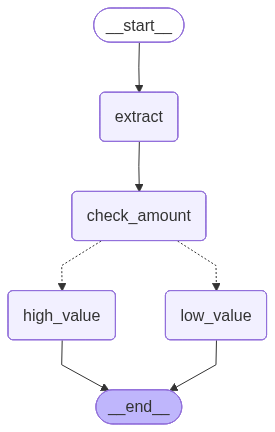

In [17]:
# draw a mermaid diagram of the graph structure
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [47]:
%pip install arize-phoenix

  Using cached aioitertools-0.13.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached aiosqlite-0.22.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached email_validator-2.3.0-py3-none-any.whl.metadata (26 kB)
  Using cached grpc_interceptor-0.15.4-py3-none-any.whl.metadata (8.4 kB)
  Using cached jmespath-1.1.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached ldap3-2.9.1-py2.py3-none-any.whl.metadata (5.4 kB)
  Using cached prometheus_client-0.24.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached pystache-0.6.8-py3-none-any.whl.metadata (14 kB)
  Using cached python_multipart-0.0.22-py3-none-any.whl.metadata (1.8 kB)
  Using cached sqlean_py-3.49.1-cp312-cp312-win_amd64.whl.metadata (4.9 kB)
  Using cached strawberry_graphql-0.287.3-py3-none-any.whl.metadata (7.6 kB)
  Using cached wrapt-1.17.3-cp312-cp312-win_amd64.whl.metadata (6.5 kB)
  Using cached lia_web-0.3.1-py3-none-any.whl.metadata (1.2 kB)
  Using cached mako-


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
# Launch a local Phoenix app for quick visualization
import phoenix as px
px.launch_app()

c:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:144: SAWarning: Skipped unsupported reflection of expression-based index ix_cumulative_llm_token_count_total
  next(self.gen)
c:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:144: SAWarning: Skipped unsupported reflection of expression-based index ix_latency
  next(self.gen)


🌍 To view the Phoenix app in your browser, visit http://localhost:6006/
📖 For more information on how to use Phoenix, check out https://arize.com/docs/phoenix


In [50]:
%pip install openinference-instrumentation-langchain opentelemetry-sdk opentelemetry-exporter-otlp

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
# Example instrumentation: register OpenTelemetry exporters and instrumentors
from phoenix.otel import register
register()

# Enable the LangChain instrumentor to automatically capture traces/metrics from any LangChain calls within the graph execution
from openinference.instrumentation.langchain import LangChainInstrumentor
LangChainInstrumentor().instrument()

Overriding of current TracerProvider is not allowed


OpenTelemetry Tracing Details
|  Phoenix Project: default
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: localhost:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



--- EXTRACTING ATTRIBUTES ---
❌ Groq Error: Extra data: line 15 column 1 (char 263)
❌ Groq Error: Extra data: line 3 column 1 (char 206)
❌ Gemini failed on all models.
❌ Gemini failed on all models.
--- CHECKING AMOUNT THRESHOLD ---
✅ Normal value invoice: $0.0
--- ACTION: AUTOMATED PROCESSING ---
✅ Invoice N/A is approved for auto-payment.
{'doc': ConversionResult(version=DoclingVersion(docling_version='2.81.0', docling_core_version='2.70.2', docling_ibm_models_version='3.12.0', docling_parse_version='5.6.0', platform_str='Windows-11-10.0.26200-SP0', py_impl_version='cpython-312', py_lang_version='3.12.9'), timestamp=None, status=<ConversionStatus.SUCCESS: 'success'>, errors=[], pages=[Page(page_no=1, size=Size(width=612.0, height=792.0), predictions=PagePredictions(layout=LayoutPrediction(clusters=[Cluster(id=17, label=<DocItemLabel.SECTION_HEADER: 'section_header'>, bbox=BoundingBox(l=461.25, t=27.770250000000033, r=575.18690625, b=55.52025000000003, coord_origin=<CoordOrigin.TOPLEF
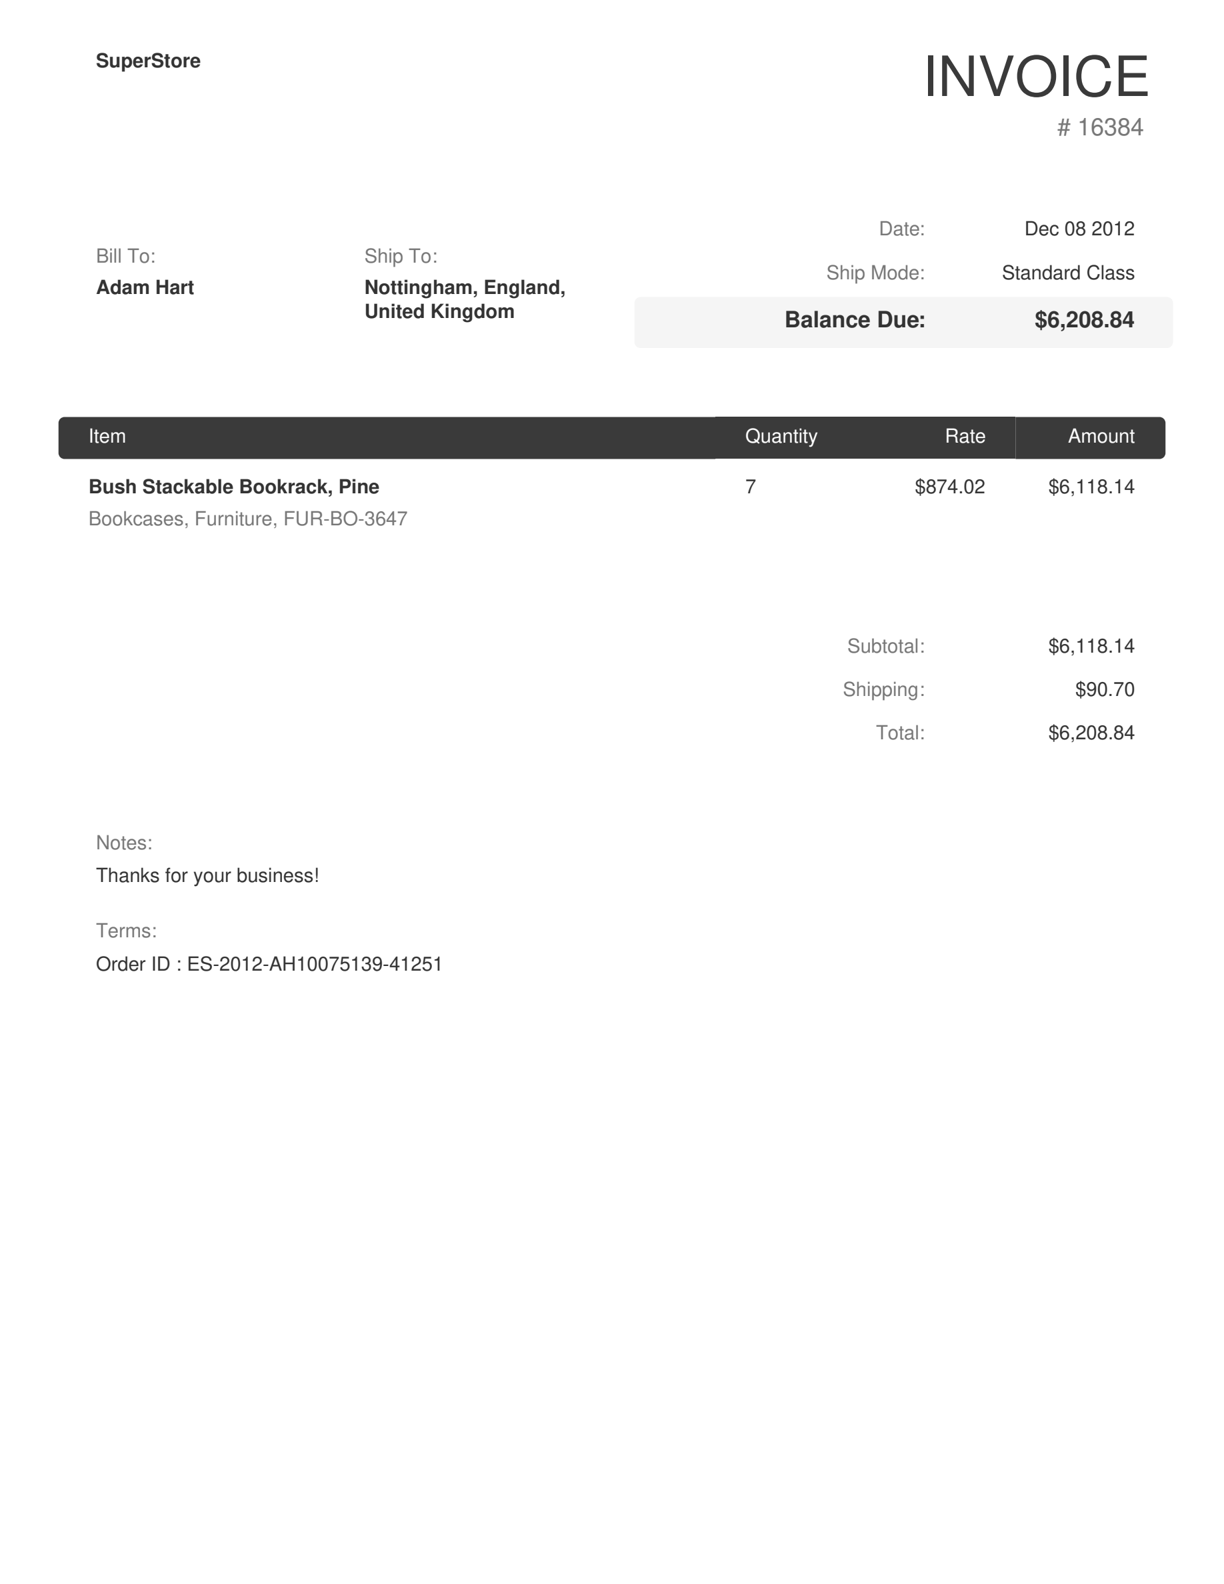

In [53]:
# Then run the graph to collect traces/metrics locally
initial_input = {
    "doc": result,             
    "markdown": document_markdown 
}
graph_result = app.invoke(initial_input)
print(graph_result)